In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_missing_value_imputed.csv')

In [4]:
df.shape

(3557, 18)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,3.25,14444.0,3,3,2,2.0,Old Property,2250.0,0,0,0,0,0,0,27
1,flat,bestech park view spa next,sector 67,2.70,11489.0,4,4,3+,9.0,Moderately Old,2127.0,0,1,0,1,0,1,149
2,house,international city by sobha phase 1,sector 109,6.75,10838.0,4,4,3+,2.0,New Property,6228.0,0,1,0,1,0,0,130
3,flat,hcbs sports ville,sohna road,0.38,5067.0,2,2,2,9.0,Relatively New,750.0,0,0,0,0,0,0,0
4,flat,m3m skywalk,sector 74,1.78,12500.0,2,2,3+,12.0,Relatively New,1582.0,0,0,0,0,0,0,63


In [6]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [7]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sector 4,3.25,3,3,2,2.0,Old Property,2250.0,0,0,0,0,0,0,27
1,flat,sector 67,2.70,4,4,3+,9.0,Moderately Old,2127.0,0,1,0,1,0,1,149
2,house,sector 109,6.75,4,4,3+,2.0,New Property,6228.0,0,1,0,1,0,0,130
3,flat,sohna road,0.38,2,2,2,9.0,Relatively New,750.0,0,0,0,0,0,0,0
4,flat,sector 74,1.78,2,2,3+,12.0,Relatively New,1582.0,0,0,0,0,0,0,63


<Axes: >

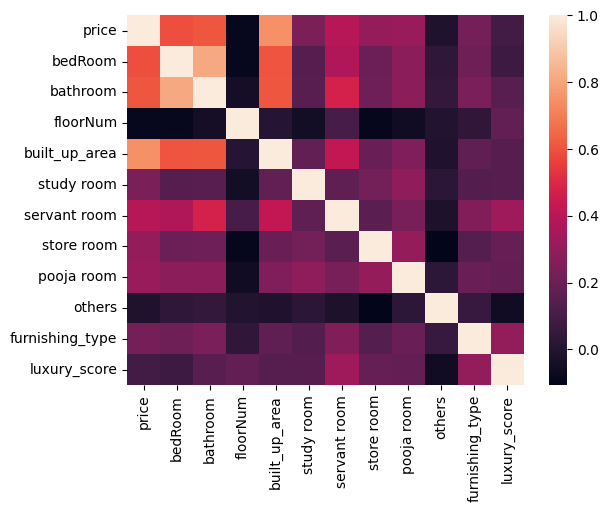

In [8]:
sns.heatmap(train_df.corr(numeric_only=True))

In [9]:
train_df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
built_up_area,0.748558
bathroom,0.609833
bedRoom,0.591329
servant room,0.392138
pooja room,0.319997
store room,0.305772
study room,0.243125
furnishing_type,0.225868
luxury_score,0.092091


## **luxury score**

<Axes: xlabel='luxury_score'>

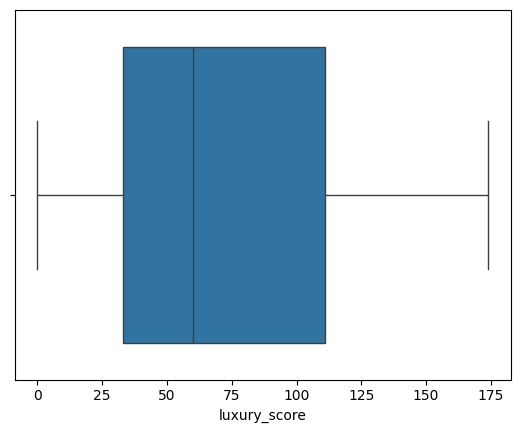

In [10]:
sns.boxplot(x=df['luxury_score'])

In [11]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [12]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [13]:
train_df.sample(5)

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
1305,flat,sohna road,0.75,3,2,3+,4.0,New Property,1201.0,0,0,0,0,0,0,101,Medium
2479,flat,sector 65,2.85,4,4,3,2.0,Relatively New,1975.0,1,1,0,0,0,0,21,Low
2751,flat,sector 67,2.32,3,4,3+,14.0,Moderately Old,1764.0,0,1,0,0,0,1,59,Medium
3136,flat,sector 28,3.00,3,5,3+,8.0,Old Property,2590.0,0,0,0,0,0,0,0,Low
2717,flat,sector 79,1.72,3,4,3,9.0,New Property,2050.0,0,0,0,0,0,0,49,Low


## **floorNum**

<Axes: xlabel='floorNum'>

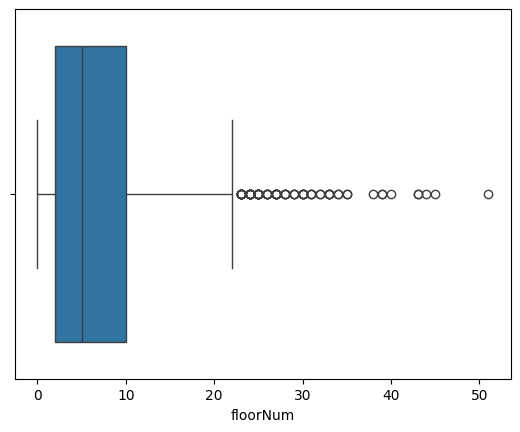

In [14]:
sns.boxplot(x=df['floorNum'])

In [15]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [16]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [17]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,house,sector 4,3.25,3,3,2,2.0,Old Property,2250.0,0,0,0,0,0,0,27,Low,Low Floor
1,flat,sector 67,2.70,4,4,3+,9.0,Moderately Old,2127.0,0,1,0,1,0,1,149,Medium,Mid Floor
2,house,sector 109,6.75,4,4,3+,2.0,New Property,6228.0,0,1,0,1,0,0,130,Medium,Low Floor
3,flat,sohna road,0.38,2,2,2,9.0,Relatively New,750.0,0,0,0,0,0,0,0,Low,Mid Floor
4,flat,sector 74,1.78,2,2,3+,12.0,Relatively New,1582.0,0,0,0,0,0,0,63,Medium,High Floor


In [18]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [19]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,house,sector 4,3.25,3,3,2,Old Property,2250.0,0,0,0,0,0,0,Low,Low Floor
1,flat,sector 67,2.70,4,4,3+,Moderately Old,2127.0,0,1,0,1,0,1,Medium,Mid Floor
2,house,sector 109,6.75,4,4,3+,New Property,6228.0,0,1,0,1,0,0,Medium,Low Floor
3,flat,sohna road,0.38,2,2,2,Relatively New,750.0,0,0,0,0,0,0,Low,Mid Floor
4,flat,sector 74,1.78,2,2,3+,Relatively New,1582.0,0,0,0,0,0,0,Medium,High Floor


In [20]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded= train_df.copy()

categorical_cols=train_df.select_dtypes(include='object').columns

# Apply label encoding to all categorical column
for col in categorical_cols:
  oe=OrdinalEncoder()
  data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
  print(oe.categories_)

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [21]:
X_label=data_label_encoded.drop(columns=['price'])
y_label=data_label_encoded['price']

In [22]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,47.0,3,3,2.0,2.0,2250.0,0,0,0,0,0,0,1.0,1.0
1,0.0,75.0,4,4,4.0,0.0,2127.0,0,1,0,1,0,1,2.0,2.0
2,1.0,11.0,4,4,4.0,1.0,6228.0,0,1,0,1,0,0,2.0,1.0
3,0.0,111.0,2,2,2.0,3.0,750.0,0,0,0,0,0,0,1.0,2.0
4,0.0,85.0,2,2,4.0,3.0,1582.0,0,0,0,0,0,0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,0.0,103.0,2,2,3.0,3.0,1225.0,1,0,0,0,0,1,1.0,0.0
3553,0.0,80.0,3,3,2.0,3.0,2167.0,1,0,0,0,0,0,2.0,2.0
3554,1.0,93.0,4,4,4.0,3.0,3240.0,0,1,1,1,0,0,1.0,2.0
3555,0.0,111.0,1,1,1.0,1.0,443.0,0,0,0,0,0,2,1.0,2.0


In [23]:
y_label

,price
0,3.25
1,2.70
2,6.75
3,0.38
4,1.78
...,...
3552,0.65
3553,1.65
3554,5.00
3555,0.28


## **Technique 1 - Correlation Analysis**

<Axes: >

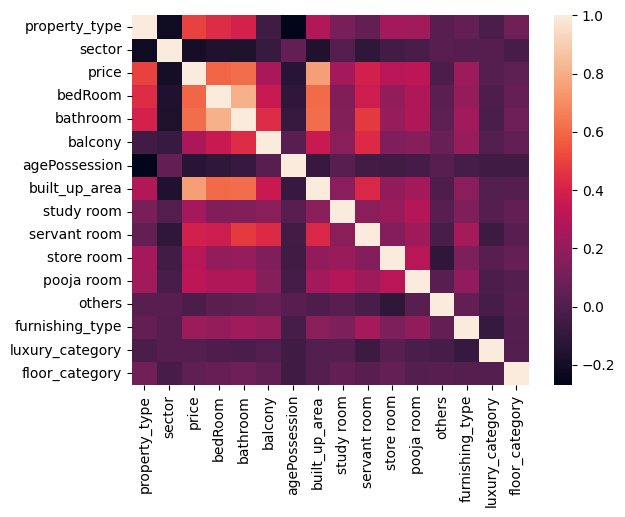

In [24]:
sns.heatmap(data_label_encoded.corr())

In [25]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.197437
1,price,1.000000
2,bedRoom,0.591329
3,bathroom,0.609833
4,balcony,0.269926
5,agePossession,-0.133435
6,built_up_area,0.748558
7,study room,0.243125
8,servant room,0.392138
9,store room,0.305772


## **Technique 2 - Random Forest Feature Importance**

In [26]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label=RandomForestRegressor(n_estimators=100,random_state=42)
rf_label.fit(X_label,y_label)

# Extract feature importance scores for label encoded data
fi_df2=pd.DataFrame({'feature':X_label.columns,'rf_importance':rf_label.feature_importances_}).sort_values('rf_importance',ascending=False)
fi_df2

,feature,rf_importance
6,built_up_area,0.649358
1,sector,0.104367
0,property_type,0.102052
3,bathroom,0.025554
2,bedRoom,0.023984
8,servant room,0.022011
5,agePossession,0.013738
4,balcony,0.011626
12,furnishing_type,0.009556
7,study room,0.007727


## **Technique 3 - Gradient Boosting Feature importances**

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label=GradientBoostingRegressor()
gb_label.fit(X_label,y_label)

# Extract feature importance scores for label encoded data
fi_df3=pd.DataFrame({'feature':X_label.columns,'gb_importance':gb_label.feature_importances_}).sort_values('gb_importance',ascending=False)
fi_df3

,feature,gb_importance
6,built_up_area,0.678304
1,sector,0.103549
0,property_type,0.095736
2,bedRoom,0.039084
3,bathroom,0.035521
8,servant room,0.022567
9,store room,0.010334
5,agePossession,0.004441
7,study room,0.004120
12,furnishing_type,0.003289


## **Technique 4-Permutation Importance**

In [28]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label,X_test_label,y_train_label,y_test_label=train_test_split(X_label,y_label,test_size=0.2,random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance=permutation_importance(rf_label,X_test_label,y_test_label,n_repeats=30,random_state=42)

# Result into a dataframe
fi_df4=pd.DataFrame({'feature':X_label.columns,'perm_importance':perm_importance.importances_mean}).sort_values('perm_importance',ascending=False)
fi_df4

,feature,perm_importance
6,built_up_area,0.724590
0,property_type,0.191922
1,sector,0.137158
2,bedRoom,0.032349
3,bathroom,0.018578
8,servant room,0.013994
4,balcony,0.007563
5,agePossession,0.005025
7,study room,0.004303
13,luxury_category,0.001795


## **Technique 5 - LASSO**

In [29]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.510764
0,property_type,0.715241
3,bathroom,0.275929
9,store room,0.199680
7,study room,0.171331
12,furnishing_type,0.164263
8,servant room,0.161570
10,pooja room,0.073758
13,luxury_category,0.055373
2,bedRoom,0.014012


## **Technique 6 - RFE**

In [30]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.648661
1,sector,0.103027
0,property_type,0.100403
2,bedRoom,0.026790
3,bathroom,0.025112
8,servant room,0.020373
5,agePossession,0.014930
4,balcony,0.012728
12,furnishing_type,0.010137
9,store room,0.007725


## **Technique 7 - Linear Regression Weights**

In [31]:
from sklearn.linear_model import LinearRegression

# Train a linear regression model on the label-encoded and standardized training data
lin_reg=LinearRegression()
lin_reg.fit(X_scaled,y_label)

# Extract coefficients
fi_df7=pd.DataFrame({'feature':X_label.columns,'reg_coeffs':lin_reg.coef_}).sort_values(by='reg_coeffs',ascending=False)
fi_df7

,feature,reg_coeffs
6,built_up_area,1.513307
0,property_type,0.715545
3,bathroom,0.282500
9,store room,0.204121
7,study room,0.179278
12,furnishing_type,0.173563
8,servant room,0.170810
10,pooja room,0.076731
13,luxury_category,0.066816
2,bedRoom,0.016804


## **Technique 8 - SHAP**

In [32]:
!pip install shap

In [33]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[ 1.16823918e+00,  5.50871987e-02, -4.69640759e-02, ...,
        -6.40109408e-02, -2.90119073e-02, -7.45670788e-02],
       [-4.99385649e-01,  5.91186344e-01, -5.61446159e-02, ...,
         2.39939064e-03, -8.89210599e-03, -1.66337322e-02],
       [ 8.49972600e-01, -8.18520320e-01, -7.17771495e-02, ...,
        -1.78059782e-02,  1.49658708e-02,  8.67924420e-03],
       ...,
       [ 1.02627194e+00, -1.27256158e+00, -8.44803232e-02, ...,
        -6.27360585e-02, -1.65434083e-02, -8.14774000e-03],
       [-1.92156773e-01, -4.20384838e-01, -4.94480304e-02, ...,
         7.65861799e-02, -8.64682130e-04, -3.12443094e-04],
       [ 1.47545963e+00, -3.12807847e-01,  1.03620073e-01, ...,
         3.71650095e-02, -2.39019679e-02, -8.31890557e-03]])

In [34]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.248383
0,property_type,0.475993
1,sector,0.382084
3,bathroom,0.121716
8,servant room,0.101426
2,bedRoom,0.051988
4,balcony,0.039434
12,furnishing_type,0.028661
5,agePossession,0.026036
14,floor_category,0.024413


In [35]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature')

In [36]:
final_fi_df

,feature,corr_coeff,rf_importance,gb_importance,perm_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
0,sector,-0.197437,0.104367,0.103549,0.137158,-0.058565,0.103027,-0.067575,0.382084
1,bedRoom,0.591329,0.023984,0.039084,0.032349,0.014012,0.026790,0.016804,0.051988
2,bathroom,0.609833,0.025554,0.035521,0.018578,0.275929,0.025112,0.282500,0.121716
3,balcony,0.269926,0.011626,0.001997,0.007563,-0.042951,0.012728,-0.065653,0.039434
4,agePossession,-0.133435,0.013738,0.004441,0.005025,-0.000000,0.014930,0.001982,0.026036
5,built_up_area,0.748558,0.649358,0.678304,0.724590,1.510764,0.648661,1.513307,1.248383
6,study room,0.243125,0.007727,0.004120,0.004303,0.171331,0.007569,0.179278,0.016908
7,servant room,0.392138,0.022011,0.022567,0.013994,0.161570,0.020373,0.170810,0.101426
8,store room,0.305772,0.006163,0.010334,0.001331,0.199680,0.007725,0.204121,0.013800
9,pooja room,0.319997,0.006898,0.000025,0.000618,0.073758,0.006286,0.076731,0.011899


In [37]:
# normalize the score
final_fi_df.iloc[0:,1:]=final_fi_df.iloc[0:,1:].divide(final_fi_df.iloc[0:,1:].sum(axis=0),axis=1)

In [38]:
df_mean=final_fi_df[['rf_importance','gb_importance','perm_importance','rfe_score','SHAP_score']].mean(axis=1)
# .iloc[0:,1:]

In [39]:
final_fi_df=pd.DataFrame({'feature':final_fi_df['feature'],'feature_importance':df_mean})

In [40]:
final_fi_df=final_fi_df.sort_values(by='feature_importance',ascending=False)
final_fi_df

,feature,feature_importance
5,built_up_area,0.711698
0,sector,0.134651
2,bathroom,0.034713
1,bedRoom,0.031764
7,servant room,0.027092
3,balcony,0.011236
4,agePossession,0.010917
11,furnishing_type,0.007209
8,store room,0.006979
6,study room,0.006844


In [41]:
# to drop study room,pooja room,others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,47.0,3,3,2.0,2.0,2250.0,0,0,0,0,0,0,1.0,1.0
1,0.0,75.0,4,4,4.0,0.0,2127.0,0,1,0,1,0,1,2.0,2.0
2,1.0,11.0,4,4,4.0,1.0,6228.0,0,1,0,1,0,0,2.0,1.0
3,0.0,111.0,2,2,2.0,3.0,750.0,0,0,0,0,0,0,1.0,2.0
4,0.0,85.0,2,2,4.0,3.0,1582.0,0,0,0,0,0,0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,0.0,103.0,2,2,3.0,3.0,1225.0,1,0,0,0,0,1,1.0,0.0
3553,0.0,80.0,3,3,2.0,3.0,2167.0,1,0,0,0,0,0,2.0,2.0
3554,1.0,93.0,4,4,4.0,3.0,3240.0,0,1,1,1,0,0,1.0,2.0
3555,0.0,111.0,1,1,1.0,1.0,443.0,0,0,0,0,0,2,1.0,2.0


In [42]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [43]:
scores.mean()

np.float64(0.8014696408163122)

In [44]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['study room','pooja room','others']), y_label, cv=5, scoring='r2')

In [45]:
scores.mean()

np.float64(0.799433426225179)

In [46]:
export_df=X_label.drop(columns=['study room','pooja room','others'])
export_df['price']=y_label

In [47]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,1.0,47.0,3,3,2.0,2.0,2250.0,0,0,0,1.0,1.0,3.25
1,0.0,75.0,4,4,4.0,0.0,2127.0,1,0,1,2.0,2.0,2.70
2,1.0,11.0,4,4,4.0,1.0,6228.0,1,0,0,2.0,1.0,6.75
3,0.0,111.0,2,2,2.0,3.0,750.0,0,0,0,1.0,2.0,0.38
4,0.0,85.0,2,2,4.0,3.0,1582.0,0,0,0,2.0,0.0,1.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,0.0,103.0,2,2,3.0,3.0,1225.0,0,0,1,1.0,0.0,0.65
3553,0.0,80.0,3,3,2.0,3.0,2167.0,0,0,0,2.0,2.0,1.65
3554,1.0,93.0,4,4,4.0,3.0,3240.0,1,1,0,1.0,2.0,5.00
3555,0.0,111.0,1,1,1.0,1.0,443.0,0,0,2,1.0,2.0,0.28


In [48]:
export_df.to_csv("gurgaon_properties_post_feature_selection.csv",index=False)